# Using AlgebraicMultigrid.jl 

## Import Packages 

In [ ]:
# include downloaded local version of AlgebraicMultigrid.jl
include("/Users/dlahaye/mytmp/AlgebraicMultigrid.jl-master/src/AlgebraicMultigrid.jl")
using .AlgebraicMultigrid

In [100]:
using LinearAlgebra
using SparseArrays
using DelimitedFiles
using IterativeSolvers
using BenchmarkTools
using Plots

## Consulting some manual pages of AlgebraicMultigrid.jl  

In [94]:
#?AlgebraicMultigrid.gs!

In [95]:
#?AlgebraicMultigrid.setup_smoother

In [96]:
#?AlgebraicMultigrid.smooth!

In [ ]:
#?AlgebraicMultigrid.ruge_stuben

In [115]:
?AlgebraicMultigrid.solve

```julia
CommonSolve.solve(args...; kwargs...)
```

Solves an equation or other mathematical problem using the algorithm specified in the arguments. Generally, the interface is:

```julia
CommonSolve.solve(prob::ProblemType, alg::SolverType; kwargs...)::SolutionType
```

where the keyword arguments are uniform across all choices of algorithms.

By default, `solve` defaults to using `solve!` on the iterator form, i.e.:

```julia
solve(args...; kwargs...) = solve!(init(args...; kwargs...))
```


In [114]:
?AlgebraicMultigrid.solve!

```julia
CommonSolve.solve!(iter)
```

Solves an equation or other mathematical problem using the algorithm specified in the arguments. Generally, the interface is:

```julia
iter = CommonSolve.init(prob::ProblemType, alg::SolverType; kwargs...)::IterType
CommonSolve.solve!(iter)::SolutionType
```

where the keyword arguments are uniform across all choices of algorithms. The `iter` type will be different for the different problem types.

---

if alg.alg === DefaultAlgorithmChoice.LUFactorization SciMLBase.solve!(cache, LUFactorization(), args...; kwargs...)) else ... end


In [108]:
# struct definition 
#?AlgebraicMultigrid.AMGSolver

In [110]:
# struct definition
#?AlgebraicMultigrid.Preconditioner

## Testing the solver 

In [101]:
# tutorial example - not sure how the boundary conditions are handled
N = 100
A = poisson(N) 
x = ones(N)
b = A*x 
# Forcing the RugeStueben algorithm to construct one level only, 
# thus forcing the multigrid algorithm to be become smoother only 
AlgebraicMultigrid.solve(A, b, RugeStubenAMG(), maxiter = 100, abstol = 1e-6)

100-element Vector{Float64}:
 0.9999998864439288
 0.9999997728878576
 0.9999998313844192
 0.9999998499913416
 0.999999884065498
 0.9999999036272775
 0.999999900178551
 0.9999998989765437
 0.9999998997014752
 0.9999998992766868
 0.9999999054333923
 0.9999999112876854
 0.9999999210262891
 ⋮
 0.9999998790798895
 0.9999998677018509
 0.9999998549416736
 0.9999998442620265
 0.9999998214182304
 0.9999997964202818
 0.9999997691524661
 0.9999997381137415
 0.9999997184189794
 0.999999656650321
 0.9999997227008961
 0.9999997477363043

## Setting up the pre-smoother and post-smoother

In [105]:
fsmoother = GaussSeidel(ForwardSweep(),1)
bsmoother = GaussSeidel(BackwardSweep(),0)
ml = ruge_stuben(A,presmoother = fsmoother, postsmoother = bsmoother,max_levels=1) 

Multilevel Solver
-----------------
Operator Complexity: 1.0
Grid Complexity: 1.0
No. of Levels: 1
Coarse Solver: Pinv
Level     Unknowns     NonZeros
-----     --------     --------
    1          100          298 [100.00%]


## Running the smoother stand-alone 

In [52]:
N = 100
A = poisson(N); 
x = ones(N);
b = A*x

#..set initial guess 
x0 = zeros(size(b))

#..set up smoother 
AlgebraicMultigrid.gs!(A, b, x0, 1, 1, size(b,1))

In [106]:
@btime AlgebraicMultigrid._solve($ml, $b, verbose=false);

  1.587 μs (6 allocations: 1.88 KiB)


## Convert the Preconditioner into a Smoother 

In [112]:
M = aspreconditioner(ml)

Main.AlgebraicMultigrid.Preconditioner{Main.AlgebraicMultigrid.MultiLevel{Main.AlgebraicMultigrid.Pinv{Float64}, GaussSeidel{ForwardSweep}, GaussSeidel{BackwardSweep}, SparseMatrixCSC{Float64, Int64}, Adjoint{Float64, SparseMatrixCSC{Float64, Int64}}, SparseMatrixCSC{Float64, Int64}, Main.AlgebraicMultigrid.MultiLevelWorkspace{Vector{Float64}, 1}}, Main.AlgebraicMultigrid.V}(Multilevel Solver
-----------------
Operator Complexity: 1.0
Grid Complexity: 1.0
No. of Levels: 1
Coarse Solver: Pinv
Level     Unknowns     NonZeros
-----     --------     --------
    1          100          298 [100.00%]
, :zero, Main.AlgebraicMultigrid.V())

## Section 1: Introduction 

More later. 

## Section 2: Build and Test Model Problem Discretization  

In [25]:
#..generates 1D test problem 
function problem(nelements)
    
    nnodes = nelements+1; h = 1/nelements; h2=h*h;

    #..construct the coefficient matrix without the boundary conditions 
    e = ones(nnodes); 
    A = Tridiagonal(-e[2:end], 2*e, -e[2:end]); 
    A = (1/h2)*sparse(A); 

    #..handle the boundary conditions in the matrix and right-hand side vector 
    A[1,1] = 1;       A[1,2] = 0;      A[2,1] = 0;       
    A[end,end-1]=0;   A[end,end] = 1;  A[end-1,end] = 0;      

    #..construct the rhs vector 
    u = ones(nnodes)
    b = A*u

    return A, b 
end 

problem (generic function with 1 method)

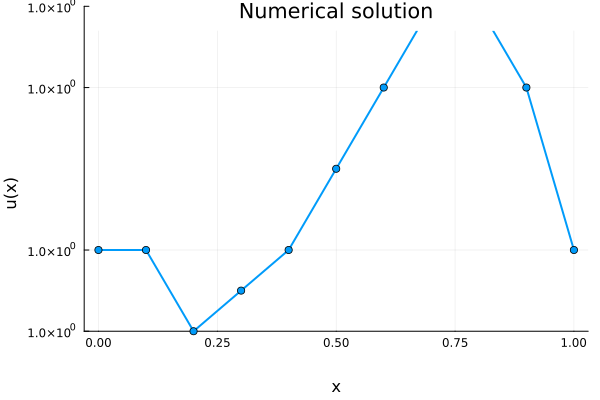

GKS: Possible loss of precision in routine SET_WINDOW


In [26]:
#..set problem size 
nelements = 10; A,b = problem(nelements)

#..solve the linear system
u = A \ b; 

#..plot computed solution 
x = [0:1/nelements:1] 
p=plot(x,u,shape=:circle,lw=2,legend=false)
xlabel!("x") 
ylabel!("u(x)")
title!("Numerical solution")

## Section 3: Build and Test the Smoother

In [32]:
#..discretize 
nelements = 10; A,b = problem(nelements)  

#..set initial guess 
x = zeros(nelements+1)

#..set up smoother 
AlgebraicMultigrid.gs!(A, b, x, 1, 100, size(b,1))

In [33]:
x

11-element Vector{Float64}:
 1.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

## Section 4: AMG as Solver  

In [117]:
#..set problem size 
nelements = 10; A,b = problem(nelements)
# nelements = 1000; A,b = problem(nelements)

#..solve 
X = AlgebraicMultigrid.solve(A, b, RugeStubenAMG(), maxiter = 100, abstol = 1e-6)

11-element Vector{Float64}:
 1.0
 0.9999999999670063
 0.9999999999340125
 0.9999999998680249
 1.000000000380214
 1.00000000108251
 0.9999999999010395
 0.9999999986700887
 0.9999999978790766
 0.9999999960276027
 1.0

In [21]:
# 1. Define custom pre- and post-smoothers
# This configures 2 iterations of Symmetric Gauss-Seidel
custom_smoother = GaussSeidel(SymmetricSweep(), 0)

# 2. Pass them to the multigrid solver constructor
ml = ruge_stuben(A, pre_smoother=custom_smoother, post_smoother=custom_smoother)

# 3. Use it as a standalone solver or preconditioner
M = aspreconditioner(ml)

AlgebraicMultigrid.Preconditioner{AlgebraicMultigrid.MultiLevel{AlgebraicMultigrid.Pinv{Float64}, GaussSeidel{SymmetricSweep}, GaussSeidel{SymmetricSweep}, SparseMatrixCSC{Float64, Int64}, Adjoint{Float64, SparseMatrixCSC{Float64, Int64}}, SparseMatrixCSC{Float64, Int64}, AlgebraicMultigrid.MultiLevelWorkspace{Vector{Float64}, 1}}, AlgebraicMultigrid.V}(Multilevel Solver
-----------------
Operator Complexity: 1.323
Grid Complexity: 1.364
No. of Levels: 2
Coarse Solver: Pinv
Level     Unknowns     NonZeros
-----     --------     --------
    1           11           31 [75.61%]
    2            4           10 [24.39%]
, :zero, AlgebraicMultigrid.V())